In [257]:
import torch
import torch.nn as nn
from torch.distributions import MultivariateNormal
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import optparse
import pickle

import matplotlib.pyplot as plt

import sac.memory as mem
from sac.feedforward import Feedforward
# import SAC
from sac.DDPG import DDPGAgent

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.set_num_threads(1)

In [326]:
import torch
from sac.feedforward import Feedforward
from sac.memory import Memory
import numpy as np


class SAC:
    """Soft Actor-Critic Agent

    Parameters:
        Q function
            Q optimizer
        policy
            policy optimizer
        alpha
        tau
        gamma
        updates per step

    Interface:
        act(obs) - produce action
        train


    NOTE: Code written by hand based on knowledge from class, papers, and reading online resources.
    The agent code is not based on an existing implementation or generated by LLMs, 
    but it uses a similar structure and utility files from the DDPG homework.

    Sources:
    1. https://spinningup.openai.com/en/latest/algorithms/sac.html
    2. https://arxiv.org/pdf/1801.01290
    """


    def __init__(self, Q1, Q2, policy, alpha, gamma, buffer, batch_size):
        self.Q1 = Q1
        self.Q2 = Q2
        self.policy = policy
        self.alpha = alpha
        self.gamma = gamma
        self.buffer = buffer
        self.batch_size = batch_size


    def act(self, obs):
        with torch.no_grad():
            actions = self.policy.act(torch.tensor(obs[None]))
            return actions[0].detach().numpy()
    
    def state(self):
        return (self.Q1.state(), self.Q2.state(), self.policy.state())

    def restore_state(self, state):
        self.Q1.restore_state(state[0])
        self.Q2.restore_state(state[1])
        self.policy.restore_state(state[2])
    
    def get_batch(self):
        to_torch = lambda x: torch.from_numpy(x.astype(np.float32))
        data=self.buffer.sample(batch=self.batch_size)
        s = to_torch(np.stack(data[:,0])) # s_t
        a = to_torch(np.stack(data[:,1])) # a_t
        rew = to_torch(np.stack(data[:,2])[:,None]) # rew  (batchsize,1)
        s_prime = to_torch(np.stack(data[:,3])) # s_t+1
        done = to_torch(np.stack(data[:,4])[:,None])
        return s, a, rew, s_prime, done

    def train(self, fit_steps):
        losses = []
        for i in range(fit_steps):
            state, action, reward, next_state, done = self.get_batch()
            next_action = self.policy.sample(state)
            t, q_target, logprob = self.compute_t(next_state, next_action)
            target = self.compute_target(t, reward, done)
            q1_loss = self.Q1.fit(state.detach(), action.detach(), target.detach())
            q2_loss = self.Q2.fit(state.detach(), action.detach(), target.detach())
            policy_loss = self.policy.step(t)
            self.update_targets()
            losses.append((q1_loss, q2_loss, policy_loss, torch.mean(q_target.detach()), torch.mean(logprob.detach())))
        return losses

    def compute_t(self, s_p, a_p):
        logprob = self.policy.logprob(s_p, a_p)
        q1 = self.Q1.target_val(s_p, a_p) 
        q2 = self.Q2.target_val(s_p, a_p)
        q_target = torch.min(q1, q2) 
        t = q_target - self.alpha * logprob
        return t, q_target, logprob
    
    def compute_target(self, t, r, d):
        y = r + self.gamma * (1-d) * t
        return y

    def update_targets(self):
        self.Q1.polyak_update()
        self.Q2.polyak_update()

    def store_transition(self, trans):
        self.buffer.add_transition(trans)
    

class QFunction:
    def __init__(self, base, target, optim, loss, tau):
        super().__init__()
        # TODO: Setup network with right input and output size (using super().__init__)
        self.model = base
        self.target = target
        self.target.load_state_dict(base.state_dict())
        self.tau = tau

        # END
        self.optimizer=optim
        self.loss = loss

    def fit(self, observations, actions, targets): # all arguments should be torch tensors
        self.model.train() # put model in training mode
        self.optimizer.zero_grad()
        # Forward pass

        pred = self.Q_value(observations,actions)
        # Compute Loss
        loss = self.loss(pred, targets)

        # Backward pass
        loss.backward()
        self.optimizer.step()
        return loss.item()

    def state(self):
        return (self.model.state_dict(), self.target.state_dict())

    def restore_state(self, state):
        self.model.load_state_dict(state[0])
        self.target.load_state_dict(state[1])
    
    def target_val(self, observations, actions):
        # TODO: implement the forward pass.
        return self.target(torch.cat((observations, actions), dim=-1))

    def Q_value(self, observations, actions):
        # TODO: implement the forward pass.
        return self.model(torch.cat((observations, actions), dim=-1))
    
    def polyak_update(self):
        Q_dict = self.model.state_dict()
        target_dict = self.target.state_dict()
        new_dict = {}
        with torch.no_grad():
            for k in Q_dict:
                new_dict[k] = self.tau * target_dict[k] + (1-self.tau) * Q_dict[k]
        self.target.load_state_dict(new_dict)
    

class TanhGaussianPolicy:

    def __init__(self, base_net, optim, action_space, exp_steps, eps):
        self.base_net = base_net
        self.optimizer = optim
        self.action_space = action_space
        self.act_dim = self.action_space.shape[0]
        self.act_scale = torch.Tensor((self.action_space.high - self.action_space.low) * 0.5)
        self.act_offset = torch.Tensor((self.action_space.high + self.action_space.low) * 0.5)
        self.exp_steps = exp_steps
        self.t = 0
        self.eps = eps

    def forward(self, state):
        output = self.base_net(state)
        mu = output[:, :self.act_dim]
        logsig = output[:, self.act_dim:]
        return mu, logsig

    def step(self, t):
        self.base_net.train() # put model in training mode
        self.optimizer.zero_grad()
        # Forward pass

        # Compute Loss
        loss = -torch.mean(t)

        # Backward pass
        loss.backward()
        self.optimizer.step()
        return loss.item()

    def state(self):
        return self.base_net.state_dict()

    def restore_state(self, state):
        self.base_net.load_state_dict(state)
    
    def scale(self, act):
        return self.act_scale * act + self.act_offset

    def act(self, state):
        if self.t < self.exp_steps:
            action = torch.tensor(np.random.uniform(self.action_space.low, self.action_space.high)[None])
        else:
            action = self.sample(state)
        self.t += 1
        return action

    def sample(self, state):
        eps = torch.randn(state.shape[0], self.act_dim)
        mu, logsig = self.forward(state)
        raw_act = torch.tanh(mu + torch.exp(logsig) * eps)
        return self.scale(raw_act)

    def logprob(self, state, action):        
        mu, logsig = self.forward(state)
        inv_scaled = (action - self.act_offset[None]) / self.act_scale[None]
        inv_scaled = torch.clip(inv_scaled, -1+self.eps, 1-self.eps)
        x = torch.atanh(inv_scaled)
        lognorm = -0.5 * torch.log(2*torch.tensor(torch.pi)) - logsig - 0.5 * torch.exp(-2 * logsig) * (x - mu) ** 2
        logprob = lognorm - torch.sum(torch.log(self.act_scale[None]) + torch.log(1 - inv_scaled ** 2), axis=-1, keepdim=True) 
        return logprob

In [345]:
env_name = "Pendulum-v1"
# creating environment
if env_name == "LunarLander-v3":
    env = gym.make(env_name, continuous = True)
else:
    env = gym.make(env_name)
render = False
log_interval = 20           # print avg reward in the interval
max_episodes = 2000 # max training episodes
max_timesteps = 2000         # max timesteps in one episode

train_iter = 1      # update networks for given batched after every episode
lr_actor  = 3e-4 # learning rate of DDPG policy
lr_critic = 3e-4
random_seed = 0
tau = 1-0.005
batch_size = 256
gamma = 0.99
alpha = 0.1
# loss = torch.nn.MSELoss()
loss = torch.nn.SmoothL1Loss()
exp_steps = 100
eps = 1e-3

# train_iter = 1     # update networks for given batched after every episode
# lr_actor  = 1e-3 # learning rate of DDPG policy
# lr_critic = 1e-3
# random_seed = 0
# tau = 0.995
# batch_size = 100
# gamma = 0.99
# alpha = 0.2
# # loss = torch.nn.SmoothL1Loss()
# loss = torch.nn.MSELoss()
# exp_steps = 10000

In [346]:
if random_seed is not None:
    torch.manual_seed(random_seed)
    np.random.seed(random_seed)



In [347]:
observation_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
hidden_sizes = [256, 256]
# hidden_sizes = [128, 128, 64]

In [348]:
Q1_base = Feedforward(observation_dim+action_dim, hidden_sizes, 1)
Q1_target = Feedforward(observation_dim+action_dim, hidden_sizes, 1)
Q1_optim = torch.optim.Adam(Q1_base.parameters(),
                                        lr=lr_critic)
Q1 = QFunction(Q1_base, Q1_target, Q1_optim, loss, tau)

Q2_base = Feedforward(observation_dim+action_dim, hidden_sizes, 1)
Q2_target = Feedforward(observation_dim+action_dim, hidden_sizes, 1)
Q2_optim = torch.optim.Adam(Q2_base.parameters(), lr=lr_critic)
Q2 = QFunction(Q2_base, Q2_target, Q2_optim, loss, tau)

policy_base = Feedforward(observation_dim, hidden_sizes, 2*action_dim)
policy_optim = torch.optim.Adam(policy_base.parameters(), lr=lr_actor)
policy = TanhGaussianPolicy(policy_base, policy_optim, env.action_space, exp_steps=exp_steps, eps=eps)
buffer = mem.Memory(int(1e6))
sac = SAC(Q1, Q2, policy, alpha=alpha, gamma=gamma, buffer=buffer, batch_size=batch_size)


In [349]:
agent = sac
agent_name = "SAC"

In [350]:
# agent = DDPGAgent(env.observation_space, env.action_space, eps = 0.1, learning_rate_actor = lr_actor,
#                      update_target_every = 100)
# agent_name = "DDPG"

In [351]:

# logging variables
rewards = []
lengths = []
losses = []
timestep = 0

def save_statistics():
    with open(f"./results/{agent_name}_{env_name}-l{lr_actor}-s{random_seed}-stat.pkl", 'wb') as f:
        pickle.dump({"rewards" : rewards, "lengths": lengths, "train": train_iter,
                        "lr": lr_actor, "losses": losses}, f)

In [352]:




# training loop
# with torch.autograd.detect_anomaly():
for i_episode in range(1, max_episodes+1):
    ob, _info = env.reset()
    total_reward=0
    for t in range(max_timesteps):
        timestep += 1
        done = False
        a = agent.act(ob)
        (ob_new, reward, done, trunc, _info) = env.step(a)
        total_reward+= reward
        agent.store_transition((ob, a, reward, ob_new, done))
        ob=ob_new
        if done or trunc: break

    losses.extend(agent.train(train_iter))

    rewards.append(total_reward)
    lengths.append(t)

    # save every 500 episodes
    if i_episode % 500 == 0:
        print("########## Saving a checkpoint... ##########")
        torch.save(agent.state(), f'./results/{agent_name}_{env_name}_{i_episode}-l{lr_actor}-s{random_seed}.pth')
        save_statistics()

    # logging
    if i_episode % log_interval == 0:
        avg_reward = np.mean(rewards[-log_interval:])
        avg_length = int(np.mean(lengths[-log_interval:]))

        print('Episode {} \t avg length: {} \t reward: {}'.format(i_episode, avg_length, avg_reward))
save_statistics()



Episode 20 	 avg length: 199 	 reward: -1249.781872068752
Episode 40 	 avg length: 199 	 reward: -1159.3560130286028
Episode 60 	 avg length: 199 	 reward: -1060.608258869564
Episode 80 	 avg length: 199 	 reward: -1102.2430438587667
Episode 100 	 avg length: 199 	 reward: -1179.896710660022
Episode 120 	 avg length: 199 	 reward: -1202.8760013514045
Episode 140 	 avg length: 199 	 reward: -1257.332762803997
Episode 160 	 avg length: 199 	 reward: -1293.3855900870494
Episode 180 	 avg length: 199 	 reward: -1233.8019931466067
Episode 200 	 avg length: 199 	 reward: -1245.481465045279
Episode 220 	 avg length: 199 	 reward: -1276.7738306503825
Episode 240 	 avg length: 199 	 reward: -1328.9574087325914
Episode 260 	 avg length: 199 	 reward: -1263.1284854407768
Episode 280 	 avg length: 199 	 reward: -1293.9286341575528
Episode 300 	 avg length: 199 	 reward: -1255.193816686382
Episode 320 	 avg length: 199 	 reward: -1296.9729774637863
Episode 340 	 avg length: 199 	 reward: -1342.8337

KeyboardInterrupt: 

In [148]:
agent_state = torch.load(f'./results/{agent_name}_{env_name}_500-l{lr_actor}-s{random_seed}.pth')

In [149]:
agent.restore_state(agent_state)

In [309]:
torch.tensor([2, 2])[None].shape

torch.Size([1, 2])

In [338]:
np.asarray(losses)

array([[ 3.90227890e+01,  3.95242691e+01,  5.68475202e-02,
        -1.90480724e-01, -1.33633220e+00],
       [ 4.40041237e+01,  4.41378174e+01,  5.63353226e-02,
        -1.92319900e-01, -1.35984576e+00],
       [ 3.33176956e+01,  3.32985001e+01,  5.55350706e-02,
        -1.90338597e-01, -1.34803534e+00],
       ...,
       [            inf,             inf, -6.31347933e+19,
         8.17186737e+00, -6.31347880e+20],
       [            inf,             inf, -7.55169479e+19,
         1.03767395e+01, -7.55169426e+20],
       [            inf,             inf, -8.25313219e+19,
         8.28726006e+00, -8.25313131e+20]], shape=(792, 5))

In [ ]:
def running_mean(x, N):
    cumsum = np.cumsum(np.insert(x, 0, 0)) 
    return (cumsum[N:] - cumsum[:-N]) / float(N)  

In [340]:
torch.tensor(1e20) ** 2

tensor(inf)

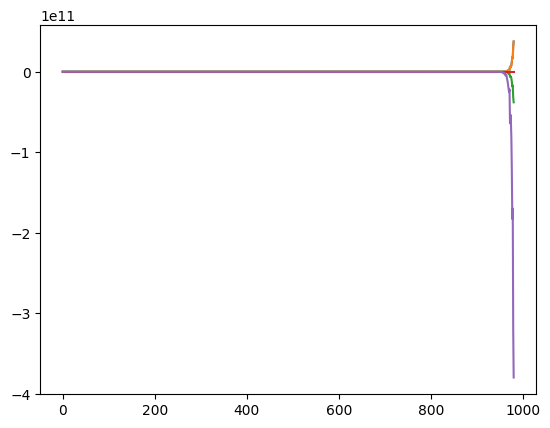

In [353]:
plt.plot(losses)

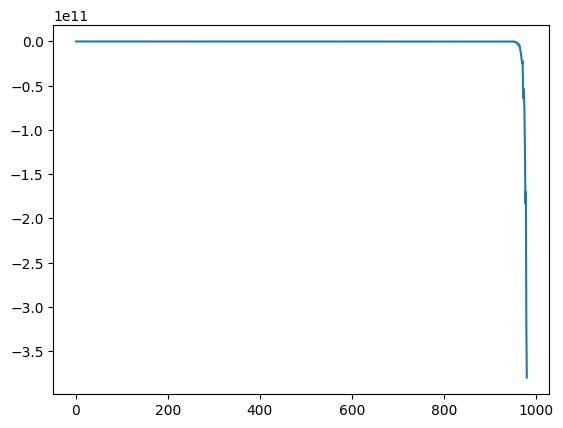

In [354]:
plt.plot(np.asarray(losses)[:, -1])

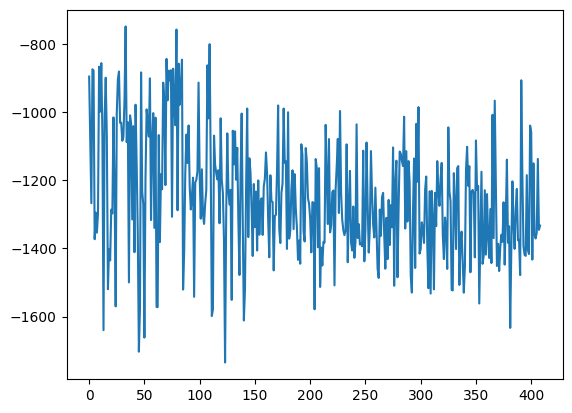

In [304]:
plt.plot(rewards)
plt.plot(running_mean(rewards, 20))

In [355]:
state, action, reward, next_state, done = agent.get_batch()

In [369]:
agent.policy.forward(state)[0][:5]

tensor([[-7.4163],
        [ 7.7682],
        [ 7.7550],
        [ 7.5497],
        [-7.4580]], grad_fn=<SliceBackward0>)

In [368]:
agent.policy.forward(state)[1][:5]

tensor([[ 12.1670],
        [-12.5571],
        [-12.5606],
        [-12.6057],
        [ 12.1500]], grad_fn=<SliceBackward0>)

In [379]:
agent.policy.sample(state)[:5]

tensor([[-2.0000],
        [ 2.0000],
        [ 2.0000],
        [ 2.0000],
        [-2.0000]], grad_fn=<SliceBackward0>)

In [377]:
agent.policy.logprob(state, agent.policy.sample(state))[:5]

tensor([[-7.5639e+00],
        [-6.3542e+11],
        [-6.3571e+11],
        [-6.2523e+11],
        [-7.5470e+00]], grad_fn=<SliceBackward0>)

In [381]:
torch.atanh(torch.tensor(0.9999))

tensor(4.9516)